In [1]:
from utils.data_loader_imagenet import get_cluster_random_loader

training_loader = get_cluster_random_loader(
    root="/Volumes/GAI/imagenet21k-train.msgpack", class_index_path="cluster_class_index.pickle", batch_size=16, num_classes=5, num_samples=10000, num_images=5, mini=False, num_workers=0, ratio=0.01)

In [2]:
training_loader.dataset.build_image_index()

In [ ]:
import gc
gc.collect()

0

In [ ]:
import torch

torch.cuda.empty_cache()  # Clears unused memory
torch.cuda.ipc_collect()  # Collects and reclaims GPU memory

In [ ]:
for batch_idx, (images, labels, pred_image, pred_label) in enumerate(training_loader):
    print(batch_idx)
    print(images.shape)
    if batch_idx == 3:
        break

0
torch.Size([16, 25, 3, 224, 224])
1
torch.Size([16, 25, 3, 224, 224])
2
torch.Size([16, 25, 3, 224, 224])
3
torch.Size([16, 25, 3, 224, 224])


: 

In [4]:
import torch.utils.benchmark as benchmark

timer = benchmark.Timer(
    stmt="for batch in dataloader: pass",
    globals={"dataloader": training_loader}
)

In [5]:
from torchvision.datasets import ImageNet

dataset = ImageNet(root="/Volumes/DFKI117/inet", split="train")

In [14]:
import numpy as np
sample = dataset[0]
img = np.array(sample[0])

In [1]:
from torchvision.datasets import ImageFolder

inet21k = ImageFolder(root="/Volumes/DFKI117/inet21k/imagenet21k_resized/imagenet21k_train")

In [14]:
sample = inet21k[1]
print(sample)

(<PIL.Image.Image image mode=RGB size=224x224 at 0x3BDC666F0>, 0)


In [10]:
idx_to_class = {v: k for k, v in dataset.wnid_to_idx.items()}

In [12]:
test_idx = [87, 155, 178, 181, 199, 217, 284, 321,
                   452, 469, 483, 541, 574, 753, 777, 788, 826, 927, 946]

test_classes = [idx_to_class[idx] for idx in test_idx]
print(test_classes)

['n01817953', 'n02086240', 'n02092339', 'n02093647', 'n02097298', 'n02102040', 'n02123597', 'n02276258', 'n02869837', 'n02939185', 'n02980441', 'n03249569', 'n03445777', 'n04040759', 'n04141327', 'n04200800', 'n04328186', 'n07613480', 'n07730033']


In [16]:
inet21k_test_idx = [inet21k.class_to_idx[cls] for cls in test_classes]

In [19]:
print(inet21k_test_idx)

[895, 1387, 1415, 1420, 1445, 1472, 1572, 1776, 2872, 3071, 3193, 3809, 4259, 5598, 5855, 5987, 6299, 7282, 7523]


In [ ]:
from simplejpeg import decode_jpeg_header, decode_jpeg, encode_jpeg
from PIL import Image
from PIL import UnidentifiedImageError
import io
import gzip

def encode_img(img, quality=85, short_side=375, long_side=500, colorsubsampling='422'):
    target_size = 3 * short_side * long_side
    # bio = io.BytesIO(data)
    im = np.array(img)
    colorspace = 'RGB'  # converted to RGB guaranteed
    compress = True  # force compression since simplejpeg failed
    # if images are CMYK or
    if colorspace == 'CMYK' or compress:
        # for CMYK or non-JPEG images,
        # quality might not be given, so assume 99
        if quality is None:
            quality = 98
        # default to subsampling 422
        # use full color resolution for small images
        # or if compression is disabled,
        # i.e. for CMYK images or if simplejpeg failed to decode
        if not compress or im.size <= 0.5*target_size:
            colorsubsampling = '444'
        # downscale large images
        if im.size > target_size*1.5:
            h, w = im.shape[:2]
            s = max(h, w)
            r = long_side/s
            h, w = int(round(r*h)), int(round(r*w))
            pil = Image.fromarray(im, 'RGB')
            im = np.array(pil.resize((w, h), resample=Image.LANCZOS))
        return encode_jpeg(im, quality=quality, colorsubsampling=colorsubsampling)

In [40]:
encode_img(img)

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x05\x03\x04\x04\x04\x03\x05\x04\x04\x04\x05\x05\x05\x06\x07\x0c\x08\x07\x07\x07\x07\x0f\x0b\x0b\t\x0c\x11\x0f\x12\x12\x11\x0f\x11\x11\x13\x16\x1c\x17\x13\x14\x1a\x15\x11\x11\x18!\x18\x1a\x1d\x1d\x1f\x1f\x1f\x13\x17"$"\x1e$\x1c\x1e\x1f\x1e\xff\xdb\x00C\x01\x05\x05\x05\x07\x06\x07\x0e\x08\x08\x0e\x1e\x14\x11\x14\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\xff\xc0\x00\x11\x08\x00\xfa\x00\xfa\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\

In [19]:
h, w = img.shape[:2]

In [21]:
from simplejpeg import encode_jpeg, decode_jpeg_header, decode_jpeg

compressed = encode_jpeg(img, quality=98, colorsubsampling='444')
original = sample[0].tobytes()

In [22]:
import sys

sys.getsizeof(compressed), sys.getsizeof(original)

(28811, 187533)

In [29]:
exclude_classes = [87, 155, 178, 181, 199, 217, 284, 321,
                   452, 469, 483, 541, 574, 753, 777, 788, 826, 927, 946]
include_classes = None

indices = []
for idx, (_, target) in enumerate(dataset.samples):
    if include_classes is not None and target not in include_classes:
        continue
    if exclude_classes is not None and target in exclude_classes:
        continue
    indices.append(idx)

In [34]:
exclude_classes = [895, 1387, 1415, 1420, 1445, 1472, 1572, 1776, 2872, 3071, 3193, 3809, 4259, 5598, 5855, 5987, 6299, 7282, 7523]
include_classes = None

indices21k = []
for idx, (_, target) in enumerate(inet21k.samples):
    if include_classes is not None and target not in include_classes:
        continue
    if exclude_classes is not None and target in exclude_classes:
        continue
    indices21k.append(idx)

In [36]:
len(indices), len(indices21k)

(1256947, 10975340)

In [21]:
from torch.utils.data import Subset
ds = Subset(dataset, indices)

In [ ]:
from datadings.writer import FileWriter

with FileWriter('/Volumes/DFKI117/imagenet-train.msgpack') as writer:
    for i, (img, label) in enumerate(ds):
        sample = {'key': str(i), 'image': img.tobytes(), 'label': label}
        writer.write(sample)

imagenet-train.msgpack exists, overwrite? [Y/n/a/?] 

In [2]:
import torch

tree = torch.load("data/imagenet21k_miil_tree.pth", weights_only=False)

In [3]:
tree.keys()

dict_keys(['class_list', 'child_2_parent', 'class_tree_list', 'class_description'])

In [4]:
import numpy as np

class_tree_list = tree['class_tree_list']
class_names = np.array(list(tree['class_description'].values()))
max_normalization_factor = 2e1
num_classes = len(class_tree_list)
class_depth = torch.zeros(num_classes)
for i in range(num_classes):
    class_depth[i] = len(class_tree_list[i]) - 1
max_depth = int(torch.max(class_depth).item())

# process semantic relations
hist_tree = torch.histc(class_depth, bins=max_depth + 1, min=0, max=max_depth).int()
ind_list = []
class_names_ind_list = []
hirarchy_level_list = []
cls = torch.tensor(np.arange(num_classes))
for i in range(max_depth):
    if hist_tree[i] > 1:
        hirarchy_level_list.append(i)
        ind_list.append(cls[class_depth == i].long())
        class_names_ind_list.append(class_names[ind_list[-1]])
hierarchy_indices_list = ind_list
hirarchy_level_list = hirarchy_level_list
class_names_ind_list = class_names_ind_list

In [17]:
class_tree_list[10]

[10, 9, 66, 65, 144]

In [1]:
import torch
import numpy as np

# Load the hierarchical structure file
tree_path = "data/imagenet21k_miil_tree.pth"
hierarchy_data = torch.load(tree_path, weights_only=False)

# Extract relevant data
class_tree_list = hierarchy_data['class_tree_list']
class_names = np.array(
    list(hierarchy_data['class_description'].values()))  # Get class names

# Compute class depth
num_classes = len(class_tree_list)
class_depth = torch.zeros(num_classes)
for i in range(num_classes):
    class_depth[i] = len(class_tree_list[i]) - 1  # Depth = length of path - 1

# Get max depth
max_depth = int(torch.max(class_depth).item())

# Compute histogram of depth levels
hist_tree = torch.histc(class_depth, bins=max_depth +
                        1, min=0, max=max_depth).int()

# Extract class indices for each hierarchy level
hierarchy_indices_list = []
class_names_ind_list = []
hierarchy_level_list = []
cls = torch.tensor(np.arange(num_classes))

for i in range(max_depth + 1):
    if hist_tree[i] > 0:
        hierarchy_level_list.append(i)
        # Indices of classes at this level
        hierarchy_indices_list.append(cls[class_depth == i].long())
        class_names_ind_list.append(class_names[hierarchy_indices_list[-1]])

# Function to get class names at a specific hierarchy level


def get_classes_at_level(level):
    if level in hierarchy_level_list:
        idx = hierarchy_level_list.index(level)
        return class_names_ind_list[idx].tolist()
    else:
        return []


# Test: Retrieve classes at hierarchy level 3
level = 3
classes_at_level_3 = get_classes_at_level(level)

# Display results
print(f"\nClasses found at level {level}: {len(classes_at_level_3)}")
print("Sample classes at level 3:", classes_at_level_3[:10])


Classes found at level 3: 2486
Sample classes at level 3: ['dressage', 'bathe', 'dip', 'dive', 'floating', 'skin_diving', 'fight', 'spar', 'Greco-Roman_wrestling', 'figure_skating']


In [6]:
import torch
import numpy as np

# Load the hierarchical structure file
tree_path = "data/imagenet21k_miil_tree.pth"
hierarchy_data = torch.load(tree_path, weights_only=False)

# Extract relevant data
class_tree_list = hierarchy_data["class_tree_list"]
class_names = np.array(
    list(hierarchy_data["class_description"].values()))  # Class names
class_labels = list(hierarchy_data["class_list"])

# Compute class depth
num_classes = len(class_tree_list)
class_depth = torch.zeros(num_classes)
for i in range(num_classes):
    class_depth[i] = len(class_tree_list[i]) - 1  # Depth = path length - 1

# Get max depth
max_depth = int(torch.max(class_depth).item())

# Create mappings of hierarchy levels
depth_to_indices = {}  # Maps hierarchy level -> class indices
class_to_index = {class_names[i]: i for i in range(
    num_classes)}  # Maps class name -> index
index_to_class = {i: class_names[i] for i in range(
    num_classes)}  # Maps index -> class name
label_to_index = {class_labels[i]: i for i in range(
    num_classes)}
index_to_label = {i: class_labels[i] for i in range(
    num_classes)}
hist_tree = torch.histc(class_depth, bins=max_depth + 1, min=0, max=max_depth).int()
ind_list = []
class_names_ind_list = []
hirarchy_level_list = []
cls = torch.tensor(np.arange(num_classes))
for i in range(max_depth):
    if hist_tree[i] > 1:
        hirarchy_level_list.append(i)
        ind_list.append(cls[class_depth == i].long())
        class_names_ind_list.append(class_names[ind_list[-1]])


for i in range(num_classes):
    level = int(class_depth[i].item())
    if level not in depth_to_indices:
        depth_to_indices[level] = []
    depth_to_indices[level].append(i)

# Function to find children of a given class at a specific level


def get_children_of_class(parent_class, parent_level):
    if parent_class not in class_to_index:
        print(f"Class '{parent_class}' not found.")
        return []

    parent_index = class_to_index[parent_class]
    children = []

    # Check all classes at the next level
    next_level = parent_level + 1
    if next_level in depth_to_indices:
        for child_index in depth_to_indices[next_level]:
            # If this class's tree path contains the parent class, it's a child
            if parent_index in class_tree_list[child_index]:
                children.append(index_to_class[child_index])

    return children


# Example: Find children of 'garment' at hierarchy level 2
parent_class = "overgarment"
parent_level = 4
children_classes = get_children_of_class(parent_class, parent_level)

# Display results
print(
    f"\nChildren of '{parent_class}' at level {parent_level}: {len(children_classes)}")
print("Sample children:", children_classes[:10])


Children of 'overgarment' at level 4: 17
Sample children: ['caftan', 'capote', 'chlamys', 'duffel_coat', 'frock_coat', 'fur_coat', 'greatcoat', 'jacket', 'lab_coat', 'poncho']


In [70]:
index_to_label[class_to_index["overgarment"]]

'n03863923'

In [54]:
len(hierarchy_data["child_2_parent"].keys()), len(set(list(hierarchy_data["child_2_parent"].keys())))

(74389, 74389)

In [80]:
def display_hierarchical_structure(hierarchy_data, max_display_depth):
    """
    Displays the hierarchical structure of the dataset up to a specified depth.

    Args:
    - hierarchy_data (dict): The hierarchical data loaded from the file.
    - max_display_depth (int): The maximum depth to display in the hierarchy.
    """
    class_tree_list = hierarchy_data["class_tree_list"]
    class_names = np.array(list(hierarchy_data["class_description"].values()))
    class_labels = list(hierarchy_data["class_list"])

    num_classes = len(class_tree_list)
    class_depth = torch.zeros(num_classes)
    for i in range(num_classes):
        class_depth[i] = len(class_tree_list[i]) - 1

    max_depth = int(torch.max(class_depth).item())

    # Create mappings of hierarchy levels
    depth_to_indices = {}
    class_to_index = {class_names[i]: i for i in range(num_classes)}
    index_to_class = {i: class_names[i] for i in range(num_classes)}
    label_to_index = {class_labels[i]: i for i in range(
    num_classes)}
    index_to_label = {i: class_labels[i] for i in range(
        num_classes)}

    for i in range(num_classes):
        level = int(class_depth[i].item())
        if level not in depth_to_indices:
            depth_to_indices[level] = []
        depth_to_indices[level].append(i)

    def print_hierarchy(level, parent_index=None):
        if level > max_display_depth:
            return
        if level not in depth_to_indices:
            return
        for idx in depth_to_indices[level]:
            if parent_index is None or parent_index in class_tree_list[idx]:
                class_name = (index_to_class[idx], index_to_label[idx])
                print("  " * level + f"- {class_name}")
                print_hierarchy(level + 1, idx)

    print("Hierarchical Structure:")
    print_hierarchy(0)

# Example usage:
# Assuming `hierarchy_data` is loaded from the file
display_hierarchical_structure(hierarchy_data, max_display_depth=3)


Hierarchical Structure:
- ('benthos', 'n00005787')
- ('cell', 'n00006484')
  - ('squamous_cell', 'n05242928')
  - ('histiocyte', 'n05450617')
  - ('lymphocyte', 'n05451384')
  - ('neutrophil', 'n05453657')
- ('person', 'n00007846')
  - ('face', 'n09618957')
  - ('acquaintance', 'n09763784')
    - ('schoolmate', 'n10560106')
  - ('astronaut', 'n09818022')
  - ('athlete', 'n09820263')
    - ('ballplayer', 'n09835506')
      - ('outfielder', 'n10386984')
    - ('basketball_player', 'n09842047')
    - ('circus_acrobat', 'n09923561')
    - ('gymnast', 'n10153594')
    - ('lineman', 'n10263411')
    - ('runner', 'n10542888')
    - ('soccer_player', 'n10618342')
    - ('speedskater', 'n10634849')
    - ('sport', 'n10638922')
    - ('tennis_player', 'n10701180')
      - ('tennis_pro', 'n10701644')
  - ('baker', 'n09833536')
  - ('ballet_dancer', 'n09834699')
  - ('beekeeper', 'n09846755')
  - ('birth', 'n09856671')
  - ('black_belt', 'n09858165')
  - ('boatman', 'n09861946')
  - ('bridesmaid',

In [81]:
len(index_to_label.keys())

10450

In [73]:
class_depth[10]

tensor(4.)

In [4]:
import torch

lr = float("1e-4")
target_lr = float("1e-07")
initial_lr = float("1e-6")
EPOCHS = 1200

params = [torch.randn(2, 2, requires_grad=True)]

optimizer = torch.optim.AdamW(params, lr=initial_lr, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, 
    lr_lambda=lambda epoch: initial_lr + (lr - initial_lr) * (epoch / 50) if epoch < 50 else lr - (lr - target_lr) * ((epoch - 50) / (EPOCHS - 50)),
)

In [18]:
import random

def get_random_class_and_children(hierarchy_data, target_level):
    """
    Selects a random class at the specified level and retrieves its children.

    Args:
    - hierarchy_data (dict): The hierarchical data loaded from the file.
    - target_level (int): The level at which to select a random class.

    Returns:
    - tuple: A tuple containing the name of the selected class and a list of its children.
    """
    class_tree_list = hierarchy_data["class_tree_list"]
    class_names = np.array(list(hierarchy_data["class_description"].values()))

    num_classes = len(class_tree_list)
    class_depth = torch.zeros(num_classes)
    for i in range(num_classes):
        class_depth[i] = len(class_tree_list[i]) - 1

    # Create mappings of hierarchy levels
    depth_to_indices = {}
    class_to_index = {class_names[i]: i for i in range(num_classes)}
    index_to_class = {i: class_names[i] for i in range(num_classes)}
    index_to_label = {i: class_labels[i] for i in range(
        num_classes)}

    for i in range(num_classes):
        level = int(class_depth[i].item())
        if level not in depth_to_indices:
            depth_to_indices[level] = []
        depth_to_indices[level].append(i)

    if target_level not in depth_to_indices:
        return None, []

    # Select a random class at the target level
    random_index = random.choice(depth_to_indices[target_level])
    random_class_name = index_to_class[random_index]

    # Get children of the selected class
    children = []
    next_level = target_level + 1
    if next_level in depth_to_indices:
        for child_index in depth_to_indices[next_level]:
            if random_index in class_tree_list[child_index]:
                children.append((index_to_class[child_index], index_to_label[child_index]))

    return random_class_name, children, index_to_label, index_to_class

# Example usage:
# Assuming `hierarchy_data` is loaded from the file
random_class, children, index_to_label, index_to_class = get_random_class_and_children(hierarchy_data, target_level=2)
print(f"Random Class: {random_class}")
print(f"Children: {children}")
print(f"Number of children classes: {len(children)}")


Random Class: shade_tree
Children: []
Number of children classes: 0


In [1]:
import torch
import numpy as np

# Load the hierarchical structure file
tree_path = "data/imagenet21k_miil_tree.pth"
hierarchy_data = torch.load(tree_path, weights_only=False)

In [2]:
# load imagenet21k class labels to index file
import json

with open('inet21k_class_to_idx.json', 'r') as convert_file: 
    class_to_idx = json.load(convert_file)

idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

In [14]:
import torch
import numpy as np
import random

class Test():
    def __init__(
            self,
            path
        ):
        super().__init__()
        hierarchy_data = torch.load(path, weights_only=False)
        self.class_tree_list = hierarchy_data["class_tree_list"]
        class_labels = list(hierarchy_data["class_list"])

        num_classes = len(self.class_tree_list)
        class_depth = torch.zeros(num_classes)
        for i in range(num_classes):
            class_depth[i] = len(self.class_tree_list[i]) - 1

        self.depth_to_indices = {}
        self.index_to_label = {i: class_labels[i] for i in range(
            num_classes)}

        for i in range(num_classes):
            level = int(class_depth[i].item())
            if level not in self.depth_to_indices:
                self.depth_to_indices[level] = []
            self.depth_to_indices[level].append(i)
    
    def get_random_class_and_children(self):
        target_level = random.randint(1, 11)
        if target_level not in self.depth_to_indices:
            return None, []

        # Select a random class at the target level
        random_index = random.choice(self.depth_to_indices[target_level])
        random_class_label = self.index_to_label[random_index]

        # Get children of the selected class
        children = []
        next_level = target_level + 1
        if next_level in self.depth_to_indices:
            for child_index in self.depth_to_indices[next_level]:
                if random_index in self.class_tree_list[child_index]:
                    children.append(self.index_to_label[child_index])
        return random_class_label, children
        

In [15]:
test = Test(path="data/imagenet21k_miil_tree.pth")

In [25]:
test.get_random_class_and_children()

('n03384891', ['n02780704', 'n03201776', 'n03239054'])

In [4]:
class_tree_list = hierarchy_data["class_tree_list"]
class_names = np.array(list(hierarchy_data["class_description"].values()))
class_labels = list(hierarchy_data["class_list"])

num_classes = len(class_tree_list)
class_depth = torch.zeros(num_classes)
for i in range(num_classes):
    class_depth[i] = len(class_tree_list[i]) - 1

depth_to_indices = {}
class_to_index = {class_names[i]: i for i in range(num_classes)}
index_to_class = {i: class_names[i] for i in range(num_classes)}
index_to_label = {i: class_labels[i] for i in range(
    num_classes)}

for i in range(num_classes):
    level = int(class_depth[i].item())
    if level not in depth_to_indices:
        depth_to_indices[level] = []
    depth_to_indices[level].append(i)

In [7]:
import random

def get_random_class_and_children(target_level):
    """
    Selects a random class at the specified level and retrieves its children.

    Args:
    - hierarchy_data (dict): The hierarchical data loaded from the file.
    - target_level (int): The level at which to select a random class.

    Returns:
    - tuple: A tuple containing the name of the selected class and a list of its children.
    """
    if target_level not in depth_to_indices:
        return None, []

    # Select a random class at the target level
    random_index = random.choice(depth_to_indices[target_level])
    random_class_name = index_to_class[random_index]

    # Get children of the selected class
    children = []
    next_level = target_level + 1
    if next_level in depth_to_indices:
        for child_index in depth_to_indices[next_level]:
            if random_index in class_tree_list[child_index]:
                children.append((index_to_class[child_index], index_to_label[child_index]))
    return random_class_name, children

In [90]:
random_class, children = get_random_class_and_children(target_level=8)
print(f"Random Class: {random_class}")
print(f"Children: {children}")
print(f"Number of children classes: {len(children)}")

Random Class: cattle
Children: [('ox', 'n02403003'), ('bull', 'n02403325'), ('cow', 'n02403454'), ('beef', 'n02404186'), ('dairy_cattle', 'n02406174')]
Number of children classes: 5


In [11]:
# translate hierarchy idx to imagenet21k idx
idx = 9093

In [15]:
cls_label, cls_name = index_to_label[idx], index_to_class[idx]

In [16]:
class_to_idx[cls_label]

9044

In [1]:
from utils.cluster_dataloader import ImageNetDataDingsSet

inet = ImageNetDataDingsSet(data_path="/Volumes/GAI/imagenet21k-train.msgpack", class_index_path="cluster_class_index.pickle",num_images=5, num_classes=10, ratio=0.01, num_samples=10000)

In [ ]:
ImageNetDataDingsSet

TypeError: 'type' object is not iterable

In [14]:
from collections import defaultdict

def compare_dictionaries(dict1, dict2):
    # Convert defaultdicts to regular dicts
    d1 = dict(dict1)
    d2 = dict(dict2)
    
    # Prepare sets for analysis
    keys1 = set(d1.keys())
    keys2 = set(d2.keys())
    
    all_keys = keys1 | keys2
    differences = {}

    for key in all_keys:
        in_d1 = key in d1
        in_d2 = key in d2
        if not in_d1:
            differences[key] = {"only_in": "dict2", "value": d2[key]}
        elif not in_d2:
            differences[key] = {"only_in": "dict1", "value": d1[key]}
        elif d1[key] != d2[key]:
            differences[key] = {"dict1": d1[key], "dict2": d2[key]}

    is_equal = not differences
    return is_equal, differences

# Example usage
dict_a = {'a': 1, 'b': 2}
dict_b = {'a': 1, 'b': 2}
dict_c = {'a': 1, 'b': 3}

d1 = defaultdict(int, {'a': 1, 'b': 2})
d2 = {'a': 1, 'b': 2}
d3 = defaultdict(list, {'a': 1, 'b': 2})
d4 = {'a': 1, 'b': 3}

print(compare_dictionaries(d1, d2))  # True
print(compare_dictionaries(d1, d3))  # True
print(compare_dictionaries(d1, d4))  # False


print(compare_dictionaries(dict_a, dict_b))  # Output: True
print(compare_dictionaries(dict_a, dict_c))  # Output: False

(True, {})
(True, {})
(False, {'b': {'dict1': 2, 'dict2': 3}})
(True, {})
(False, {'b': {'dict1': 2, 'dict2': 3}})


In [20]:
class_index2 = inet.class_index

In [23]:
import pickle
with open("cluster_class_index.pickle", "wb") as f:
    pickle.dump(class_index2, f)

In [24]:
with open("cluster_class_index.pickle", "rb") as f:
    class_index3 = pickle.load(f)

In [25]:
compare_dictionaries(class_index3, class_index2)

(True, {})

In [9]:
len(class_index.keys())

10375

In [10]:
len(inet.class_index.keys())

10375

In [14]:
class_index = inet.class_index

In [ ]:
inet.build_image_index()

In [5]:
inet.data.keys()

dict_keys([9873, 3568, 3583, 6107, 2416, 10231, 6983, 2545, 9096, 1939, 10345, 2386, 2161, 9605, 4235, 6603, 6581, 5260, 9122, 9958, 327, 1145, 7170, 659, 9142, 622, 5665, 4412, 7187, 1872, 31, 3811, 2169, 9710, 8559, 1141, 2880, 7699, 7880, 1031, 4042, 451, 581, 3824, 2985, 6712, 10209, 5064, 10262, 2063, 7510, 1702, 4279, 8593, 1361, 9022, 6462, 3291, 8532, 4739, 3218, 798, 2093, 9585, 6418, 4928, 2129, 2077, 8656, 5341, 2088, 109, 6402, 7641, 9610, 10076, 9044, 769, 112, 8596, 4201, 9355, 4646, 5425, 7198, 3899, 8164, 10342, 925, 7515, 1863, 2488, 660, 9798, 6144, 357, 4446, 2944, 5381, 5228, 4233, 4450, 1998])

In [39]:
idx_to_class[9096]

'n12086539'

In [44]:
class_to_idx['n12086539']

9096

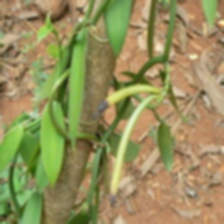

In [46]:
import torchvision

torchvision.transforms.functional.to_pil_image(inet.data[9096][1], mode=None)

test

In [1]:
from utils.cluster_dataloader import SemanticSimilarityDataDingsSet


dataset = SemanticSimilarityDataDingsSet(
    hierarchy_path="data/imagenet21k_miil_tree.pth",
    class_index_path="inet21k_class_to_idx.json",
    data_path="/Volumes/DFKI117/imagenet21k-train.msgpack", num_images=5, num_classes=10, ratio=0.01, num_samples=10000
)

100%|██████████| 10975335/10975335 [06:26<00:00, 28374.77it/s]


In [2]:
dataset.resample()

children


In [3]:
i = 0
for images, labels, pred_image, pred_label in dataset:
    print(images.shape)
    i += 1
    if i == 5:
        break

torch.Size([50, 3, 224, 224])
torch.Size([50, 3, 224, 224])
torch.Size([50, 3, 224, 224])
torch.Size([50, 3, 224, 224])
torch.Size([50, 3, 224, 224])


In [5]:
dataset.resample()

In [6]:
dataset.resample_counter

4

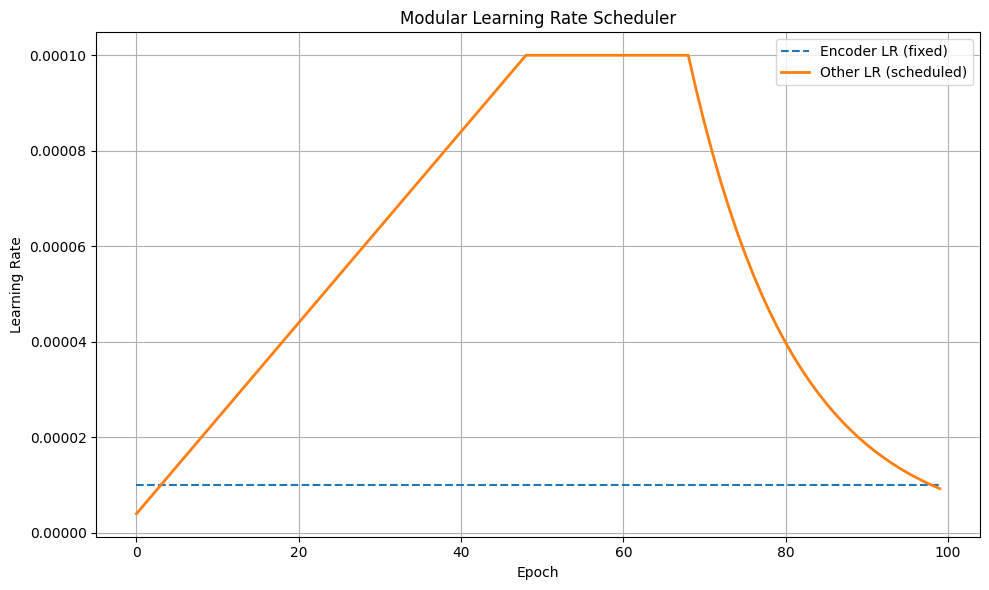

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === Dummy Model ===
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(10, 20),
            nn.ReLU(),
            nn.Linear(20, 30),
        )
        self.head = nn.Linear(30, 1)

    def forward(self, x):
        x = self.encoder(x)
        return self.head(x)

# === Modular LR Scheduler ===
class CustomLRScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(
        self,
        optimizer,
        epochs,
        param_group_index=None,
        lr_max=1e-4,
        lr_min=1e-5,
        warmup_epochs=50,
        plateau_epochs=20,
        last_epoch=-1
    ):
        self.epochs = epochs
        self.lr_max = lr_max
        self.lr_min = lr_min
        self.warmup_epochs = warmup_epochs
        self.plateau_epochs = plateau_epochs
        self.decay_epochs = epochs - (warmup_epochs + plateau_epochs)

        if param_group_index is None:
            self.param_group_index = "all"
        elif isinstance(param_group_index, int):
            self.param_group_index = [param_group_index]
        else:
            self.param_group_index = param_group_index

        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        epoch = self.last_epoch + 1

        if epoch <= self.warmup_epochs:
            scheduled_lr = self.lr_max * (epoch / self.warmup_epochs)
        elif epoch <= self.warmup_epochs + self.plateau_epochs:
            scheduled_lr = self.lr_max
        else:
            decay_epoch = epoch - (self.warmup_epochs + self.plateau_epochs)
            decay_factor = decay_epoch / self.decay_epochs
            scheduled_lr = self.lr_max * (self.lr_min / self.lr_max) ** decay_factor

        new_lrs = []
        for i, group in enumerate(self.optimizer.param_groups):
            if self.param_group_index == "all" or i in self.param_group_index:
                new_lrs.append(scheduled_lr)
            else:
                new_lrs.append(group['lr'])  # unchanged
        return new_lrs

# === Set up model, optimizer, scheduler ===
model = DummyModel()
encoder = model.encoder

initial_lr = 1e-5
encoder_params = list(encoder.parameters())
encoder_param_ids = {id(p) for p in encoder_params}
other_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]

optimizer = optim.AdamW([
    {'params': encoder_params, 'lr': initial_lr},  # group 0
    {'params': other_params, 'lr': 0.0},           # group 1
])

scheduler = CustomLRScheduler(
    optimizer=optimizer,
    epochs=100,
    param_group_index=1  # Only schedule non-encoder group
)

# === Training simulation + recording LRs ===
encoder_lrs = []
other_lrs = []

for epoch in range(100):
    optimizer.step()
    scheduler.step()
    encoder_lrs.append(optimizer.param_groups[0]['lr'])
    other_lrs.append(optimizer.param_groups[1]['lr'])

# === Plot the learning rates ===
plt.figure(figsize=(10, 6))
plt.plot(encoder_lrs, label="Encoder LR (fixed)", linestyle='--')
plt.plot(other_lrs, label="Other LR (scheduled)", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Modular Learning Rate Scheduler")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


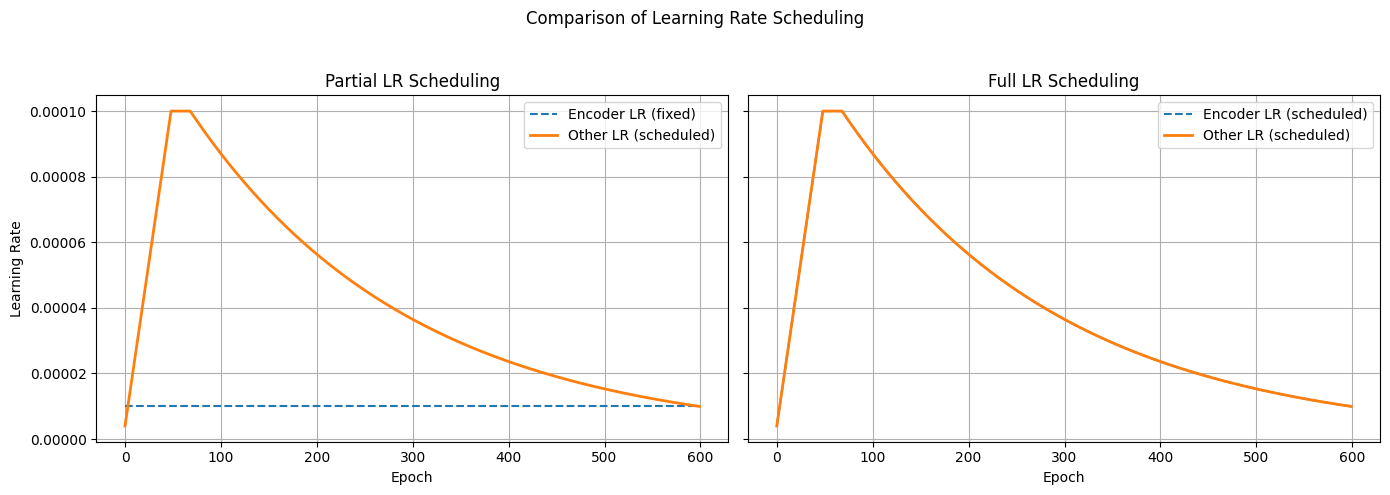

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === Dummy Model ===
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(10, 20),
            nn.ReLU(),
            nn.Linear(20, 30),
        )
        self.head = nn.Linear(30, 1)

    def forward(self, x):
        x = self.encoder(x)
        return self.head(x)

# === Modular LR Scheduler ===
class CustomLRScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(
        self,
        optimizer,
        epochs,
        param_group_index=None,
        lr_max=1e-4,
        lr_min=1e-5,
        warmup_epochs=50,
        plateau_epochs=20,
        last_epoch=-1
    ):
        self.epochs = epochs
        self.lr_max = lr_max
        self.lr_min = lr_min
        self.warmup_epochs = warmup_epochs
        self.plateau_epochs = plateau_epochs
        self.decay_epochs = epochs - (warmup_epochs + plateau_epochs)

        if param_group_index is None:
            self.param_group_index = "all"
        elif isinstance(param_group_index, int):
            self.param_group_index = [param_group_index]
        else:
            self.param_group_index = param_group_index

        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        epoch = self.last_epoch + 1

        if epoch <= self.warmup_epochs:
            scheduled_lr = self.lr_max * (epoch / self.warmup_epochs)
        elif epoch <= self.warmup_epochs + self.plateau_epochs:
            scheduled_lr = self.lr_max
        else:
            decay_epoch = epoch - (self.warmup_epochs + self.plateau_epochs)
            decay_factor = decay_epoch / self.decay_epochs
            scheduled_lr = self.lr_max * (self.lr_min / self.lr_max) ** decay_factor

        new_lrs = []
        for i, group in enumerate(self.optimizer.param_groups):
            if self.param_group_index == "all" or i in self.param_group_index:
                new_lrs.append(scheduled_lr)
            else:
                new_lrs.append(group['lr'])  # unchanged
        return new_lrs

# === Training Simulation Function ===
def simulate_training(apply_to_all=False):
    model = DummyModel()
    encoder = model.encoder

    initial_lr = 1e-5
    encoder_params = list(encoder.parameters())
    encoder_param_ids = {id(p) for p in encoder_params}
    other_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]

    optimizer = optim.AdamW([
        {'params': encoder_params, 'lr': 0.0 if apply_to_all else initial_lr},  # group 0
        {'params': other_params, 'lr': 0.0},                                   # group 1
    ])

    scheduler = CustomLRScheduler(
        optimizer=optimizer,
        epochs=600,
        param_group_index=None if apply_to_all else 1,  # None = all groups
        lr_min=1e-5,
        lr_max=1e-4
    )

    encoder_lrs = []
    other_lrs = []

    for epoch in range(600):
        optimizer.step()
        scheduler.step()
        encoder_lrs.append(optimizer.param_groups[0]['lr'])
        other_lrs.append(optimizer.param_groups[1]['lr'])

    return encoder_lrs, other_lrs

# === Run both simulations ===
enc_lrs_partial, other_lrs_partial = simulate_training(apply_to_all=False)
enc_lrs_full, other_lrs_full = simulate_training(apply_to_all=True)

# === Plotting ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Partial Schedule Plot ---
axs[0].plot(enc_lrs_partial, label="Encoder LR (fixed)", linestyle='--')
axs[0].plot(other_lrs_partial, label="Other LR (scheduled)", linewidth=2)
axs[0].set_title("Partial LR Scheduling")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Learning Rate")
axs[0].legend()
axs[0].grid(True)

# --- Full Schedule Plot ---
axs[1].plot(enc_lrs_full, label="Encoder LR (scheduled)", linestyle='--')
axs[1].plot(other_lrs_full, label="Other LR (scheduled)", linewidth=2)
axs[1].set_title("Full LR Scheduling")
axs[1].set_xlabel("Epoch")
axs[1].legend()
axs[1].grid(True)

plt.suptitle("Comparison of Learning Rate Scheduling")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [8]:
from model.pretrained_viznet import VizNetWrapper
from model.model_PictSure import CustomTransformerModel
device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
encoder = VizNetWrapper(path="./weights/vit_triplet_imagenet.pth", device=device).to(device)

model = CustomTransformerModel(encoder, 10, nheads=8, nlayer=4, device=device)
print("Model created")
model.to(device)

param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

Model created
model size: 492.007MB


/Users/lukasschiesser/Desktop/papers/embed-then-classify/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
from model.pretrained_viznet import VizNetWrapper
from model.model_PictSure import CustomTransformerModel, ResNetWrapper
from torchvision import models
import torch

device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )

classifier = models.resnet18(pretrained=True)
encoder = ResNetWrapper(classifier)
model = CustomTransformerModel(encoder, 10, nheads=8, nlayer=4, device=device)
print("Model created")
model.to(device)

param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

/Users/lukasschiesser/Desktop/papers/embed-then-classify/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/lukasschiesser/Desktop/papers/embed-then-classify/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/Users/lukasschiesser/Desktop/papers/embed-then-classify/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model created
model size: 203.949MB


In [5]:
import torch

te = torch.rand((51, 224, 224, 3), dtype=torch.float32)

In [7]:
single_batch = (te.element_size() * te.nelement()) / 1024**2 
print(single_batch, " MB")
print(single_batch * 16, " MB")

29.28515625  MB
468.5625  MB


In [16]:
from torchinfo import summary
summary(model, input_size=[(16, 50, 224, 224, 3), (16, 50, 1), (16, 1, 224, 224, 3)], dtypes=[torch.float, torch.long, torch.float], device="mps")

Layer (type:depth-idx)                        Output Shape              Param #
CustomTransformerModel                        [16, 10]                  8,399,872
├─VizNetWrapper: 1-1                          [16, 50, 768]             152,064
│    └─VisionTransformer: 2-2                 --                        (recursive)
│    │    └─PatchEmbed: 3-1                   [800, 196, 768]           590,592
│    │    └─Dropout: 3-2                      [800, 197, 768]           --
│    │    └─ModuleList: 3-8                   --                        (recursive)
│    │    └─LayerNorm: 3-4                    [800, 197, 768]           1,536
│    │    └─Linear: 3-5                       [800, 1000]               769,000
├─VizNetWrapper: 1-2                          [16, 1, 768]              (recursive)
│    └─VisionTransformer: 2-2                 --                        (recursive)
│    │    └─PatchEmbed: 3-6                   [16, 196, 768]            (recursive)
│    │    └─Dropout: 3-7 

In [4]:
from torchinfo import summary
summary(model, input_size=[(16, 50, 224, 224, 3), (16, 50, 1), (16, 1, 224, 224, 3)], dtypes=[torch.float, torch.long, torch.float], device="mps")

Layer (type:depth-idx)                             Output Shape              Param #
CustomTransformerModel                             [16, 10]                  8,399,872
├─ResNetWrapper: 1-1                               [16, 50, 512]             --
│    └─Sequential: 2-1                             [800, 512]                --
│    │    └─Conv2d: 3-1                            [800, 64, 112, 112]       9,408
│    │    └─BatchNorm2d: 3-2                       [800, 64, 112, 112]       128
│    │    └─ReLU: 3-3                              [800, 64, 112, 112]       --
│    │    └─MaxPool2d: 3-4                         [800, 64, 56, 56]         --
│    │    └─Sequential: 3-5                        [800, 64, 56, 56]         147,968
│    │    └─Sequential: 3-6                        [800, 128, 28, 28]        525,568
│    │    └─Sequential: 3-7                        [800, 256, 14, 14]        2,099,712
│    │    └─Sequential: 3-8                        [800, 512, 7, 7]          8,393,728


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === Dummy Model ===
class DummyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(10, 20),
            nn.ReLU(),
            nn.Linear(20, 30),
        )
        self.head = nn.Linear(30, 1)

    def forward(self, x):
        x = self.encoder(x)
        return self.head(x)

# === Modular LR Scheduler ===
class CustomLRScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(
        self,
        optimizer,
        epochs,
        param_group_index=None,
        lr_max=1e-4,
        lr_min=1e-5,
        warmup_epochs=50,
        plateau_epochs=20,
        last_epoch=-1
    ):
        self.epochs = epochs
        self.lr_max = lr_max
        self.lr_min = lr_min
        self.warmup_epochs = warmup_epochs
        self.plateau_epochs = plateau_epochs
        self.decay_epochs = epochs - (warmup_epochs + plateau_epochs)

        if param_group_index is None:
            self.param_group_index = "all"
        elif isinstance(param_group_index, int):
            self.param_group_index = [param_group_index]
        else:
            self.param_group_index = param_group_index

        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        epoch = self.last_epoch + 1

        if epoch <= self.warmup_epochs:
            scheduled_lr = self.lr_max * (epoch / self.warmup_epochs)
        elif epoch <= self.warmup_epochs + self.plateau_epochs:
            scheduled_lr = self.lr_max
        else:
            decay_epoch = epoch - (self.warmup_epochs + self.plateau_epochs)
            decay_factor = decay_epoch / self.decay_epochs
            scheduled_lr = self.lr_max * (self.lr_min / self.lr_max) ** decay_factor

        new_lrs = []
        for i, group in enumerate(self.optimizer.param_groups):
            if self.param_group_index == "all" or i in self.param_group_index:
                new_lrs.append(scheduled_lr)
            else:
                new_lrs.append(group['lr'])  # unchanged
        return new_lrs

In [4]:
def simulate_training(apply_to_all=False, freeze_encoder_until=100):
    model = DummyModel()
    encoder = model.encoder

    # Initially freeze encoder
    for p in encoder.parameters():
        p.requires_grad = False

    encoder_params = list(encoder.parameters())
    encoder_param_ids = {id(p) for p in encoder_params}
    other_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]

    optimizer = optim.AdamW([
        {'params': encoder_params, 'lr': 0},  # frozen initially
        {'params': other_params, 'lr': 0},    # scheduled from 0
    ])

    scheduler = CustomLRScheduler(
        optimizer=optimizer,
        epochs=200,  # simulate 200 epochs total
        param_group_index=None if apply_to_all else 1  # Apply to all or only other layers
    )

    encoder_lrs = []
    other_lrs = []

    for epoch in range(200):
        # Unfreeze encoder at given epoch
        if epoch == freeze_encoder_until:
            for p in encoder.parameters():
                p.requires_grad = True
                optimizer.param_groups[0]['lr'] = 1e-5

        optimizer.step()
        scheduler.step()
        if any(p.requires_grad for p in optimizer.param_groups[0]["params"]):
            encoder_lrs.append(optimizer.param_groups[0]['lr'])
        else:
            encoder_lrs.append(None)
        other_lrs.append(optimizer.param_groups[1]['lr'])
    print(scheduler.get_last_lr())

    return encoder_lrs, other_lrs


In [7]:
def trim_zero_lr(lrs):
    """Return (epochs, values) starting from the first non-zero LR."""
    for i, lr in enumerate(lrs):
        return list(range(i, len(lrs))), lrs[i:]
    return [], []

[1e-05, 9.82443745837425e-06]
[9.82443745837425e-06, 9.82443745837425e-06]


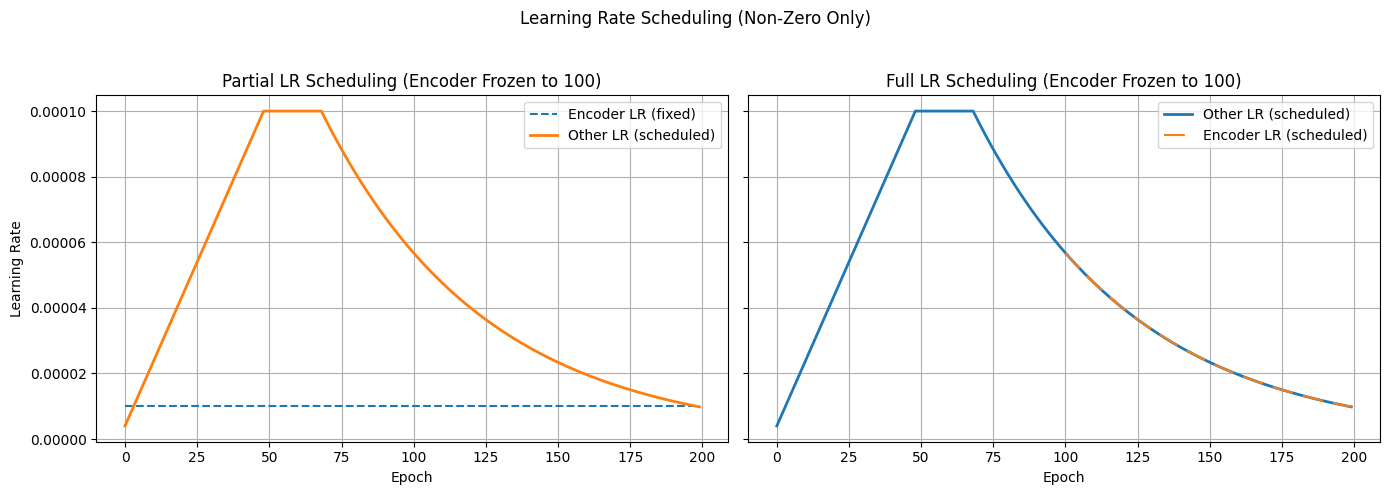

In [19]:
# Run both schedules with freezing
enc_lrs_partial, other_lrs_partial = simulate_training(apply_to_all=False, freeze_encoder_until=0)
enc_lrs_full, other_lrs_full = simulate_training(apply_to_all=True, freeze_encoder_until=100)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Partial Schedule Plot ---
epochs_enc, enc_vals = trim_zero_lr(enc_lrs_partial)
epochs_other, other_vals = trim_zero_lr(other_lrs_partial)

if enc_vals:
    axs[0].plot(epochs_enc, enc_vals, label="Encoder LR (fixed)", linestyle='--')
if other_vals:
    axs[0].plot(epochs_other, other_vals, label="Other LR (scheduled)", linewidth=2)

axs[0].set_title("Partial LR Scheduling (Encoder Frozen to 100)")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Learning Rate")
axs[0].legend()
axs[0].grid(True)

# --- Full Schedule Plot ---
epochs_enc_full, enc_vals_full = trim_zero_lr(enc_lrs_full)
epochs_other_full, other_vals_full = trim_zero_lr(other_lrs_full)


if other_vals_full:
    axs[1].plot(epochs_other_full, other_vals_full, label="Other LR (scheduled)", linewidth=2)
if enc_vals_full:
    axs[1].plot(epochs_enc_full, enc_vals_full, label="Encoder LR (scheduled)", linestyle='--', dashes=(10, 5))


axs[1].set_title("Full LR Scheduling (Encoder Frozen to 100)")
axs[1].set_xlabel("Epoch")
axs[1].legend()
axs[1].grid(True)

plt.suptitle("Learning Rate Scheduling (Non-Zero Only)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [1]:
from torchvision.datasets import ImageNet

inet = ImageNet(root="/Users/lukasschiesser/Desktop/papers/CAML/data")

In [4]:
for k, v in inet.wnid_to_idx.items():
    print(k, v)
    break

n01440764 0


In [6]:
idx_to_wnid = {v: k for k, v in inet.wnid_to_idx.items()}

In [7]:
mini_list = [
    'n04201297', 'n04204347', 'n04239074', 'n04277352', 'n04370456',
    'n04409515', 'n04456115', 'n04479046', 'n04487394', 'n04525038',
    'n04591713', 'n04599235', 'n07565083', 'n07613480', 'n07695742',
    'n07714571', 'n07717410', 'n07753275', 'n10148035', 'n12768682'
]

mini_idxs = [inet.wnid_to_idx[item] for item in mini_list]



In [8]:
test_classes = [87, 155, 178, 181, 199, 217, 284, 321,
                    452, 469, 483, 541, 574, 753, 777, 788, 826, 927, 946]

In [11]:
[overlap for overlap in test_classes if overlap in mini_idxs]

[927]